# 04 Single-run CO₂ dense-gas POC (Lake Kivu)
This notebook runs a **single 72-hour proof-of-concept** simulation for a limnic-eruption-style CO₂ release.

Key changes vs earlier prototype:
- Uses a **theoretical upper-limit CO₂ inventory** (~300 km³ STP = 3e11 m³ STP) with a `release_fraction` knob.
- **Instantaneous eruption** as a **disk** centered on Lake Kivu centroid; all volume stacked into a thick near-ground layer.
- **Two-layer model**: `H_base` hugs terrain and spreads via slope-flow; `H_top` is wind-mixed and wind-advected.
- Wind **strips only the top layer**; terrain controls the base layer.

Inputs expected from previous notebooks:
- `data/processed/static_layers.json` (from Notebook 3)
- aligned rasters in `data/processed/`.


In [1]:

import os, json, math, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

np.set_printoptions(edgeitems=3, linewidth=140, suppress=True)
pd.set_option("display.max_colwidth", 200)

PROJECT_ROOT = Path(".").resolve()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
RUNS_DIR = PROJECT_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

STATIC_PATH = PROC_DIR / "static_layers.json"
assert STATIC_PATH.exists(), f"Missing {STATIC_PATH}. Run Notebook 3."

static = json.loads(STATIC_PATH.read_text())
print("[INFO] Loaded static:", STATIC_PATH)
print("[INFO] CRS:", static["crs"], "| shape:", static["shape"], "| dx/dy:", static["dx_m"], static["dy_m"])


[INFO] Loaded static: C:\Users\nachi\Data\GitHubProjects\Lake Kivu\kivu_limnic_scenarios\notebooks\data\processed\static_layers.json
[INFO] CRS: EPSG:32735 | shape: [1675, 1067] | dx/dy: 250.0 250.0


## Load grids and static layers

[CHECK] shapes: (1675, 1067) (1675, 1067) (1675, 1067) (1675, 1067)
[CHECK] CRS all equal?  True
[CHECK] Transform equal? True
[GRID] dx,dy: 250.0 250.0 | cell_area: 62500.0
[MASK] lake pixels: 41467 water pixels: 190519 land pixels: 1596706
[SOURCE] row,col: (348, 486) | inside lake? True


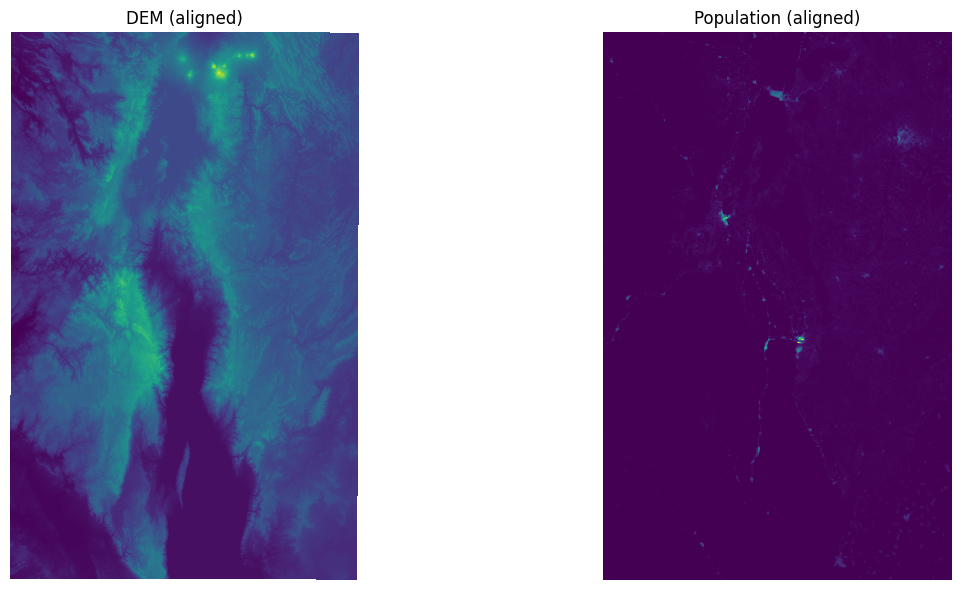

In [2]:

def load_raster(path):
    ds = rasterio.open(path)
    arr = ds.read(1)
    return ds, arr

paths = static["paths"]

dem_ds, dem = load_raster(paths["dem"])
pop_ds, pop = load_raster(paths["pop"])
u_ds, u_slope = load_raster(paths["u_slope"])
v_ds, v_slope = load_raster(paths["v_slope"])
ml_ds, mask_lake = load_raster(paths["mask_lake"])
mw_ds, mask_water = load_raster(paths["mask_water"])
mL_ds, mask_land = load_raster(paths["mask_land"])
gt_ds, _ = load_raster(paths["grid_template"])

H, W = dem.shape
dx = float(static["dx_m"]); dy = float(static["dy_m"])
cell_area = dx * dy

source_idx = json.loads(Path(paths["source_index"]).read_text())
src_r, src_c = int(source_idx["row"]), int(source_idx["col"])

print("[CHECK] shapes:", dem.shape, pop.shape, u_slope.shape, mask_lake.shape)
print("[CHECK] CRS all equal? ", dem_ds.crs == pop_ds.crs == u_ds.crs == v_ds.crs == ml_ds.crs == gt_ds.crs)
print("[CHECK] Transform equal?", dem_ds.transform == pop_ds.transform == u_ds.transform == v_ds.transform == ml_ds.transform == gt_ds.transform)
print("[GRID] dx,dy:", dx, dy, "| cell_area:", cell_area)

# cast
dem = dem.astype("float32")
pop = pop.astype("float32")
u_slope = u_slope.astype("float32")
v_slope = v_slope.astype("float32")

print("[MASK] lake pixels:", int(mask_lake.sum()), "water pixels:", int(mask_water.sum()), "land pixels:", int(mask_land.sum()))
print("[SOURCE] row,col:", (src_r, src_c), "| inside lake?", bool(mask_lake[src_r, src_c] == 1))

# quick visuals
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(dem, interpolation="nearest"); ax[0].set_title("DEM (aligned)")
ax[1].imshow(pop, interpolation="nearest"); ax[1].set_title("Population (aligned)")
for a in ax: a.set_axis_off()
plt.tight_layout(); plt.show()


## Scenario configuration (single run)

In [3]:

# ====== SINGLE RUN CONFIG ======
scenario = {
    "duration_h": 72,
    "dt_report_h": 1,            # hourly metrics
    "dt_internal_s": 120,        # internal dt (seconds). Keep small for stability.

    # Upper-limit inventory (commonly cited order): 300 km^3 STP CO2 => 3e11 m^3 STP
    "co2_inventory_upper_m3_stp": 3.0e11,
    "release_fraction": 1.0,     # POC worst case; try 0.01 .. 0.2 for smaller releases

    # Instantaneous disk eruption footprint
    "eruption_radius_m": 3000,   # tune
    "constrain_disk_to_lake": True,

    # Wind affects ONLY TOP layer
    "wind_speed_mps": 2.0,
    "wind_dir_deg_from": 90.0,   # meteorological FROM

    # Terrain flow affects ONLY BASE layer
    "slope_speed_mode": "tanh",  # "raw" or "tanh"
    "slope_tanh_beta": 0.6,
    "slope_vmax_mps": float(static["params"]["slope_vmax_mps"]),

    # Diffusion
    "K_base_m2ps": 2.0,
    "K_top_m2ps": 20.0,

    # Coupling & losses
    "entrain_rate_1ps": 2.0e-5,      # base->top
    "entrain_wind_gain": 1.0,        # multiplier by |wind|
    "strip_coeff_1ps_per_mps": 2.0e-4,  # top loss = coeff * |wind|
    "base_background_loss_1ps": 2.0e-6,

    # Concentration mapping
    "H_mix_m": 50.0,             # ppm = clip(H_total/H_mix,0..1)*1e6

    # plotting cadence
    "plot_every_report_hours": 6
}

scenario["released_volume_STP_m3"] = scenario["co2_inventory_upper_m3_stp"] * scenario["release_fraction"]

print(json.dumps(scenario, indent=2))


{
  "duration_h": 72,
  "dt_report_h": 1,
  "dt_internal_s": 120,
  "co2_inventory_upper_m3_stp": 300000000000.0,
  "release_fraction": 1.0,
  "eruption_radius_m": 3000,
  "constrain_disk_to_lake": true,
  "wind_speed_mps": 2.0,
  "wind_dir_deg_from": 90.0,
  "slope_speed_mode": "tanh",
  "slope_tanh_beta": 0.6,
  "slope_vmax_mps": 1.0,
  "K_base_m2ps": 2.0,
  "K_top_m2ps": 20.0,
  "entrain_rate_1ps": 2e-05,
  "entrain_wind_gain": 1.0,
  "strip_coeff_1ps_per_mps": 0.0002,
  "base_background_loss_1ps": 2e-06,
  "H_mix_m": 50.0,
  "plot_every_report_hours": 6,
  "released_volume_STP_m3": 300000000000.0
}


## Utilities: wind, slope shaping, advection, diffusion, losses, metrics

In [4]:

def wind_to_uv(speed_mps, dir_from_deg):
    # meteorological FROM -> TO
    dir_to = (dir_from_deg + 180.0) % 360.0
    rad = np.deg2rad(dir_to)
    u = speed_mps * np.sin(rad)  # +east
    v = speed_mps * np.cos(rad)  # +north
    return float(u), float(v)

def shape_slope_velocity(u, v, mode="raw", vmax=1.0, beta=1.0):
    u = u.astype("float32"); v = v.astype("float32")
    if mode == "raw":
        return u, v
    speed = np.sqrt(u*u + v*v)
    if mode == "tanh":
        s = speed / (vmax + 1e-12)
        new_speed = vmax * np.tanh(beta * s)
        scale = np.where(speed > 0, new_speed / (speed + 1e-12), 0.0).astype("float32")
        return (u * scale).astype("float32"), (v * scale).astype("float32")
    raise ValueError("mode must be 'raw' or 'tanh'")

def advect_upwind(Hf, u, v, dt, dx, dy):
    Hf = Hf.astype("float32")
    u = u.astype("float32"); v = v.astype("float32")

    # edge padding
    H_left  = np.pad(Hf, ((0,0),(1,0)), mode="edge")[:, :-1]
    H_right = np.pad(Hf, ((0,0),(0,1)), mode="edge")[:, 1:]
    H_up    = np.pad(Hf, ((1,0),(0,0)), mode="edge")[:-1, :]
    H_down  = np.pad(Hf, ((0,1),(0,0)), mode="edge")[1:, :]

    dHdx = np.where(u >= 0, (Hf - H_left)/dx, (H_right - Hf)/dx)
    dHdy = np.where(v >= 0, (Hf - H_up)/dy, (H_down - Hf)/dy)

    return (Hf - dt*(u*dHdx + v*dHdy)).astype("float32")

def diffuse_laplacian(Hf, K, dt, dx, dy):
    Hf = Hf.astype("float32")
    H_left  = np.pad(Hf, ((0,0),(1,0)), mode="edge")[:, :-1]
    H_right = np.pad(Hf, ((0,0),(0,1)), mode="edge")[:, 1:]
    H_up    = np.pad(Hf, ((1,0),(0,0)), mode="edge")[:-1, :]
    H_down  = np.pad(Hf, ((0,1),(0,0)), mode="edge")[1:, :]

    lap = (H_left - 2*Hf + H_right)/(dx*dx) + (H_up - 2*Hf + H_down)/(dy*dy)
    return (Hf + (K*dt)*lap).astype("float32")

def apply_loss(Hf, lam, dt):
    return (Hf * np.exp(-lam * dt)).astype("float32")

def H_to_ppm(H_total, H_mix_m):
    C = np.clip(H_total / (H_mix_m + 1e-12), 0.0, 1.0)
    return (C * 1e6).astype("float32")

def disk_mask(H, W, center_r, center_c, radius_m, dx, dy, mask_limit=None):
    rr = np.arange(H)[:, None]
    cc = np.arange(W)[None, :]
    dr_m = (rr - center_r) * dy
    dc_m = (cc - center_c) * dx
    disk = ((dr_m*dr_m + dc_m*dc_m) <= radius_m*radius_m).astype(np.uint8)
    if mask_limit is not None:
        disk = (disk & (mask_limit.astype(np.uint8))).astype(np.uint8)
    return disk

THRESH_DANGER = 50_000.0
THRESH_LETHAL = 100_000.0

def weighted_centroid(Hw, transform):
    Hw = np.where(np.isfinite(Hw) & (Hw > 0), Hw, 0.0)
    mass = float(Hw.sum())
    if mass <= 0:
        return (np.nan, np.nan)
    rr = np.arange(Hw.shape[0])[:, None]
    cc = np.arange(Hw.shape[1])[None, :]
    r_bar = float((Hw * rr).sum() / mass)
    c_bar = float((Hw * cc).sum() / mass)
    from rasterio.transform import xy
    x_bar, y_bar = xy(transform, r_bar, c_bar)
    return (float(x_bar), float(y_bar))

def farthest_front(mask, src_r, src_c, dx, dy):
    idx = np.argwhere(mask)
    if idx.size == 0:
        return 0.0
    dr = (idx[:,0] - src_r) * dy
    dc = (idx[:,1] - src_c) * dx
    return float(np.sqrt(dr*dr + dc*dc).max())

def compute_metrics(t_hr, H_base, H_top, ppm, pop, cell_area, src_r, src_c, transform,
                    entrained_m3_step, base_lost_m3_step, stripped_m3_step):
    H_total = H_base + H_top

    vol_base = float(np.nansum(H_base) * cell_area)
    vol_top  = float(np.nansum(H_top) * cell_area)
    vol_tot  = float(np.nansum(H_total) * cell_area)

    max_base = float(np.nanmax(H_base)); max_top = float(np.nanmax(H_top)); max_tot = float(np.nanmax(H_total))
    p95_ppm = float(np.nanpercentile(ppm[np.isfinite(ppm)], 95)) if np.isfinite(ppm).any() else np.nan
    max_ppm = float(np.nanmax(ppm))

    m_d = (ppm >= THRESH_DANGER)
    m_l = (ppm >= THRESH_LETHAL)

    area_d_km2 = float(m_d.sum() * cell_area / 1e6)
    area_l_km2 = float(m_l.sum() * cell_area / 1e6)

    pop_safe = np.where(np.isfinite(pop), pop, 0.0)
    pop_d = float(np.sum(pop_safe[m_d]))
    pop_l = float(np.sum(pop_safe[m_l]))

    # footprints for each layer
    eps = 1e-6
    area_base_km2 = float((H_base > eps).sum() * cell_area / 1e6)
    area_top_km2  = float((H_top  > eps).sum() * cell_area / 1e6)

    # fronts
    front_d_m = farthest_front(m_d, src_r, src_c, dx, dy)
    front_l_m = farthest_front(m_l, src_r, src_c, dx, dy)
    front_base_m = farthest_front(H_base > eps, src_r, src_c, dx, dy)
    front_top_m  = farthest_front(H_top  > eps, src_r, src_c, dx, dy)

    cx_base, cy_base = weighted_centroid(H_base, transform)
    cx_top,  cy_top  = weighted_centroid(H_top, transform)
    cx_tot,  cy_tot  = weighted_centroid(H_total, transform)

    return {
        "time_hr": float(t_hr),

        "vol_base_m3": vol_base,
        "vol_top_m3": vol_top,
        "vol_total_m3": vol_tot,

        "max_H_base_m": max_base,
        "max_H_top_m": max_top,
        "max_H_total_m": max_tot,

        "max_ppm": max_ppm,
        "p95_ppm": p95_ppm,

        "area_base_km2": area_base_km2,
        "area_top_km2": area_top_km2,

        "area_danger_km2": area_d_km2,
        "area_lethal_km2": area_l_km2,
        "pop_danger": pop_d,
        "pop_lethal": pop_l,

        "front_danger_m": front_d_m,
        "front_lethal_m": front_l_m,
        "front_base_m": front_base_m,
        "front_top_m": front_top_m,

        "centroid_base_x": cx_base,
        "centroid_base_y": cy_base,
        "centroid_top_x": cx_top,
        "centroid_top_y": cy_top,
        "centroid_total_x": cx_tot,
        "centroid_total_y": cy_tot,

        "entrained_m3_step": float(entrained_m3_step),
        "base_lost_m3_step": float(base_lost_m3_step),
        "top_stripped_m3_step": float(stripped_m3_step),
    }


## Initialize eruption as a disk and stack all released CO₂ volume into H_base

[ERUPTION] disk pixels: 256 disk area km^2: 16.0
[ERUPTION] released_m3: 3.000e+11 | H0 (m): 1.88e+04


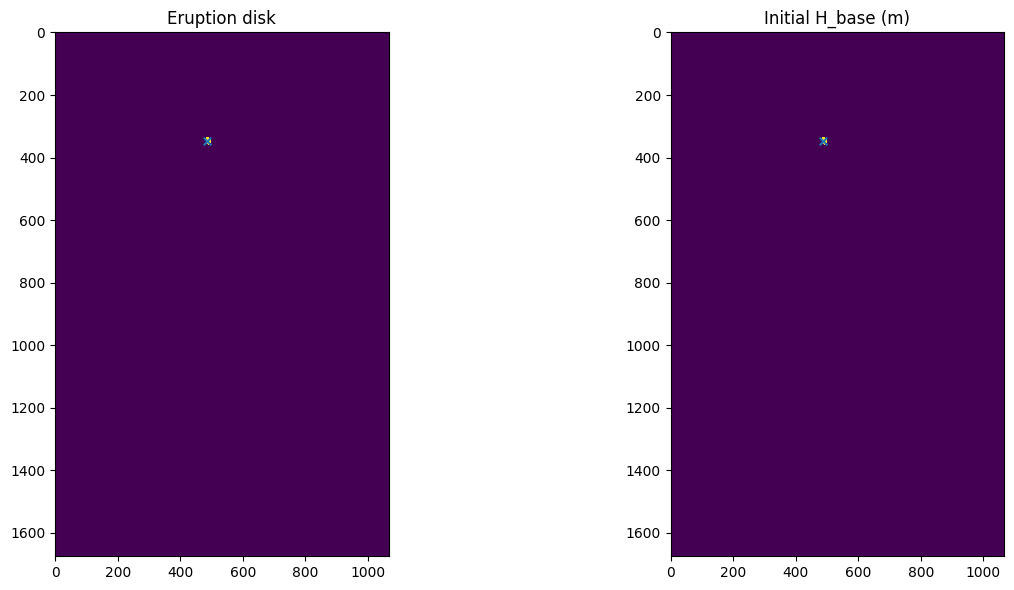

In [5]:

# Disk footprint
limit_mask = mask_lake if scenario["constrain_disk_to_lake"] else None
disk = disk_mask(H, W, src_r, src_c, scenario["eruption_radius_m"], dx, dy, mask_limit=limit_mask)

disk_px = int(disk.sum())
disk_area_m2 = disk_px * cell_area
print("[ERUPTION] disk pixels:", disk_px, "disk area km^2:", disk_area_m2 / 1e6)

assert disk_px > 0, "Disk footprint is empty. Increase eruption_radius_m or check masks."

released_m3 = float(scenario["released_volume_STP_m3"])
H0 = released_m3 / (disk_area_m2 + 1e-12)
print("[ERUPTION] released_m3:", f"{released_m3:.3e}", "| H0 (m):", f"{H0:.3g}")

H_base = np.zeros((H, W), dtype="float32")
H_top  = np.zeros((H, W), dtype="float32")
H_base[disk == 1] = H0

plt.figure(figsize=(14,6))
plt.subplot(1,2,1); plt.imshow(disk, interpolation="nearest"); plt.scatter([src_c],[src_r], s=30, marker="x"); plt.title("Eruption disk")
plt.subplot(1,2,2); plt.imshow(H_base, interpolation="nearest"); plt.scatter([src_c],[src_r], s=30, marker="x"); plt.title("Initial H_base (m)")
plt.tight_layout(); plt.show()


## Run simulation (72h) — two-layer: terrain base + wind top

In [ ]:

# Prepare run folder
run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = RUNS_DIR / f"single_run_dense2layer_{run_id}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("[RUN] dir:", RUN_DIR)

(RUN_DIR / "scenario_config.json").write_text(json.dumps(scenario, indent=2))
(RUN_DIR / "static_layers.json").write_text(json.dumps(static, indent=2))

# Velocities
u_wind, v_wind = wind_to_uv(scenario["wind_speed_mps"], scenario["wind_dir_deg_from"])
wind_mag = float(np.sqrt(u_wind*u_wind + v_wind*v_wind))
print("[WIND] u,v (m/s):", (u_wind, v_wind), "| |wind|:", wind_mag)

u_base, v_base = shape_slope_velocity(u_slope, v_slope,
                                      mode=scenario["slope_speed_mode"],
                                      vmax=scenario["slope_vmax_mps"],
                                      beta=scenario["slope_tanh_beta"])

# Wind only for TOP (constant fields)
u_top = u_wind * np.ones((H, W), dtype="float32")
v_top = v_wind * np.ones((H, W), dtype="float32")

# CFL check (rough)
u_max = float(np.nanmax(np.abs(u_base)))  # base max
v_max = float(np.nanmax(np.abs(v_base)))
u_top_max = abs(u_wind); v_top_max = abs(v_wind)

dt_cfl = min(0.5 * dx / (max(u_max, u_top_max) + 1e-12),
             0.5 * dy / (max(v_max, v_top_max) + 1e-12))
print("[CFL] suggested dt <= %.1fs" % dt_cfl, "| chosen dt_internal_s:", scenario["dt_internal_s"])
if scenario["dt_internal_s"] > dt_cfl:
    print("[WARN] dt_internal exceeds CFL suggestion. Consider lowering dt_internal_s.")

# time
duration_s = scenario["duration_h"] * 3600.0
dt = float(scenario["dt_internal_s"])
dt_report_s = scenario["dt_report_h"] * 3600.0
n_steps = int(np.ceil(duration_s / dt))
report_every = max(1, int(round(dt_report_s / dt)))
print("[TIME] steps:", n_steps, "| report_every:", report_every, "internal steps")

plot_every_reports = max(1, int(round(scenario["plot_every_report_hours"] / scenario["dt_report_h"])))

# cumulatives
cum_entrained = 0.0
cum_base_lost = 0.0
cum_top_stripped = 0.0

# metrics rows
metrics = []

def snapshot(t_hr, H_base, H_top, ppm, out_png):
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    ax[0,0].imshow(H_base, interpolation="nearest"); ax[0,0].set_title(f"H_base (m) t={t_hr:.1f}h")
    ax[0,1].imshow(H_top, interpolation="nearest");  ax[0,1].set_title("H_top (m)")
    ax[1,0].imshow(ppm, interpolation="nearest");    ax[1,0].set_title("ppm (H_total)")
    lethal = (ppm >= THRESH_LETHAL).astype(np.uint8)
    ax[1,1].imshow(dem, interpolation="nearest"); ax[1,1].imshow(lethal, alpha=0.35, interpolation="nearest")
    ax[1,1].set_title("Lethal overlay (>=100k ppm)")
    for a in ax.ravel():
        a.scatter([src_c], [src_r], s=25, marker="x")
        a.set_axis_off()
    plt.tight_layout()
    fig.savefig(out_png, dpi=140)
    plt.close(fig)

print("[SIM] starting...")
for step in range(n_steps + 1):
    t_s = step * dt
    t_hr = t_s / 3600.0

    # ===== BASE: terrain spread =====
    H_base = advect_upwind(H_base, u_base, v_base, dt, dx, dy)
    H_base = diffuse_laplacian(H_base, scenario["K_base_m2ps"], dt, dx, dy)

    # ===== TOP: wind shear layer =====
    H_top = advect_upwind(H_top, u_top, v_top, dt, dx, dy)
    H_top = diffuse_laplacian(H_top, scenario["K_top_m2ps"], dt, dx, dy)

    # ===== Coupling: entrainment base -> top (wind enhanced) =====
    entrain_rate = scenario["entrain_rate_1ps"] * (1.0 + scenario["entrain_wind_gain"] * wind_mag)
    dE = (entrain_rate * dt) * H_base
    dE = np.minimum(dE, H_base)
    H_base -= dE
    H_top  += dE
    entrained_m3_step = float(np.nansum(dE) * cell_area)
    cum_entrained += entrained_m3_step

    # ===== Losses =====
    # base background loss
    base_before = float(np.nansum(H_base) * cell_area)
    H_base = apply_loss(H_base, scenario["base_background_loss_1ps"], dt)
    base_after = float(np.nansum(H_base) * cell_area)
    base_lost_m3_step = max(0.0, base_before - base_after)
    cum_base_lost += base_lost_m3_step

    # top stripping by wind
    strip_rate = scenario["strip_coeff_1ps_per_mps"] * wind_mag
    top_before = float(np.nansum(H_top) * cell_area)
    H_top = apply_loss(H_top, strip_rate, dt)
    top_after = float(np.nansum(H_top) * cell_area)
    stripped_m3_step = max(0.0, top_before - top_after)
    cum_top_stripped += stripped_m3_step

    # non-negative
    H_base = np.maximum(H_base, 0).astype("float32")
    H_top  = np.maximum(H_top, 0).astype("float32")

    # ===== Reporting =====
    if step % max(1, int(round(3600/dt))) == 0:  # roughly hourly debug print
        H_tot = H_base + H_top
        ppm_now = H_to_ppm(H_tot, scenario["H_mix_m"])
        print(f"[t={t_hr:6.1f}h] vol_base={float(np.nansum(H_base)*cell_area):.3e} "
              f"| vol_top={float(np.nansum(H_top)*cell_area):.3e} "
              f"| ppm_max={float(np.nanmax(ppm_now)):.3g} "
              f"| entrain_cum={cum_entrained:.3e} "
              f"| strip_cum={cum_top_stripped:.3e}")

    if step % report_every == 0:
        H_tot = H_base + H_top
        ppm = H_to_ppm(H_tot, scenario["H_mix_m"])

        m = compute_metrics(t_hr, H_base, H_top, ppm, pop, cell_area, src_r, src_c, gt_ds.transform,
                            entrained_m3_step, base_lost_m3_step, stripped_m3_step)

        # add cumulatives and scenario constants
        m.update({
            "cum_entrained_m3": float(cum_entrained),
            "cum_base_lost_m3": float(cum_base_lost),
            "cum_top_stripped_m3": float(cum_top_stripped),
            "released_volume_STP_m3": float(scenario["released_volume_STP_m3"]),
            "eruption_radius_m": float(scenario["eruption_radius_m"]),
            "wind_u_mps": float(u_wind),
            "wind_v_mps": float(v_wind),
            "wind_mag_mps": float(wind_mag),
            "K_base_m2ps": float(scenario["K_base_m2ps"]),
            "K_top_m2ps": float(scenario["K_top_m2ps"]),
            "entrain_rate_1ps_base": float(scenario["entrain_rate_1ps"]),
            "strip_coeff_1ps_per_mps": float(scenario["strip_coeff_1ps_per_mps"]),
            "H_mix_m": float(scenario["H_mix_m"]),
            "dt_internal_s": float(dt),
            "dt_report_h": float(scenario["dt_report_h"]),
        })
        metrics.append(m)

        report_idx = int(round(t_hr / scenario["dt_report_h"]))
        if report_idx % plot_every_reports == 0:
            out_png = RUN_DIR / f"snapshot_t{int(round(t_hr)):03d}h.png"
            snapshot(t_hr, H_base, H_top, ppm, out_png)
            print("[PLOT] saved", out_png.name)

metrics_df = pd.DataFrame(metrics)
metrics_path = RUN_DIR / "metrics_hourly.csv"
metrics_df.to_csv(metrics_path, index=False)
print("\n[WRITE] metrics:", metrics_path, "| rows:", len(metrics_df), "| cols:", metrics_df.shape[1])

# quick plots
plt.figure(figsize=(12,5))
plt.plot(metrics_df["time_hr"], metrics_df["pop_lethal"], label="pop_lethal")
plt.plot(metrics_df["time_hr"], metrics_df["pop_danger"], label="pop_danger")
plt.xlabel("time (h)"); plt.ylabel("population"); plt.title("Exposure over time"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,5))
plt.plot(metrics_df["time_hr"], metrics_df["front_base_m"], label="front_base_m")
plt.plot(metrics_df["time_hr"], metrics_df["front_top_m"], label="front_top_m")
plt.plot(metrics_df["time_hr"], metrics_df["front_lethal_m"], label="front_lethal_m")
plt.xlabel("time (h)"); plt.ylabel("meters"); plt.title("Front distances"); plt.legend(); plt.tight_layout(); plt.show()

print("\n[SUMMARY]")
print(" max ppm:", float(metrics_df["max_ppm"].max()))
print(" max pop_lethal:", float(metrics_df["pop_lethal"].max()))
print(" max pop_danger:", float(metrics_df["pop_danger"].max()))
print(" final vol_total_m3:", float(metrics_df["vol_total_m3"].iloc[-1]))
print(" residual (released - cum_losses - final):",
      float(scenario["released_volume_STP_m3"] - (cum_base_lost + cum_top_stripped) - metrics_df["vol_total_m3"].iloc[-1]))

# close rasters
for ds in [dem_ds, pop_ds, u_ds, v_ds, ml_ds, mw_ds, mL_ds, gt_ds]:
    ds.close()


[RUN] dir: C:\Users\nachi\Data\GitHubProjects\Lake Kivu\kivu_limnic_scenarios\notebooks\runs\single_run_dense2layer_20260302_171745
[WIND] u,v (m/s): (-2.0, -3.6739403974420594e-16) | |wind|: 2.0
[CFL] suggested dt <= 62.5s | chosen dt_internal_s: 120
[WARN] dt_internal exceeds CFL suggestion. Consider lowering dt_internal_s.
[TIME] steps: 2160 | report_every: 30 internal steps
[SIM] starting...
[t=   0.0h] vol_base=2.896e+11 | vol_top=2.002e+09 | ppm_max=1e+06 | entrain_cum=2.101e+09 | strip_cum=9.846e+07
[PLOT] saved snapshot_t000h.png
[t=   1.0h] vol_base=1.704e+11 | vol_top=2.270e+10 | ppm_max=1e+06 | entrain_cum=4.752e+10 | strip_cum=2.482e+10
[t=   2.0h] vol_base=1.303e+11 | vol_top=2.156e+10 | ppm_max=1e+06 | entrain_cum=7.979e+10 | strip_cum=5.823e+10
[t=   3.0h] vol_base=1.016e+11 | vol_top=1.766e+10 | ppm_max=1e+06 | entrain_cum=1.048e+11 | strip_cum=8.711e+10
[t=   4.0h] vol_base=7.967e+10 | vol_top=1.401e+10 | ppm_max=1e+06 | entrain_cum=1.243e+11 | strip_cum=1.103e+11
[t= 

C:\Users\nachi\AppData\Local\Temp\ipykernel_156032\2412823100.py:116: RuntimeWarning: All-NaN slice encountered
  f"| ppm_max={float(np.nanmax(ppm_now)):.3g} "
C:\Users\nachi\AppData\Local\Temp\ipykernel_156032\1462424082.py:95: RuntimeWarning: All-NaN slice encountered
  max_base = float(np.nanmax(H_base)); max_top = float(np.nanmax(H_top)); max_tot = float(np.nanmax(H_total))
C:\Users\nachi\AppData\Local\Temp\ipykernel_156032\1462424082.py:97: RuntimeWarning: All-NaN slice encountered
  max_ppm = float(np.nanmax(ppm))


[t=  11.0h] vol_base=0.000e+00 | vol_top=0.000e+00 | ppm_max=nan | entrain_cum=1.539e+11 | strip_cum=1.489e+11
[t=  12.0h] vol_base=0.000e+00 | vol_top=0.000e+00 | ppm_max=nan | entrain_cum=1.539e+11 | strip_cum=1.489e+11
[PLOT] saved snapshot_t012h.png


## Files produced
- `runs/<run_id>/metrics_hourly.csv`
- `runs/<run_id>/snapshot_tXXXh.png` every few hours (configurable)
